<h2><center>Assignment 4</center></h2>
<h3><center>Programming for Data Science 2026</center></h3>
<b><center>Deadline: 14:00, March 26, 2026</center></b>

- The exercise will be marked as **passed** if you get **at least 10/16** points.

- Exercises must be handed in via **ILIAS** (Homework assignments). Submit your work as a **compressed (.zip)** file containing **one** `.py` **or** `.ipynb` file with **all exercises**.

- The name of **both** the `.zip` file and the `.py`/`.ipynb` file must be the *SurnameName* of the **two group members**, separated by an underscore.  
  Example: Tim Tabellen and Lara Lambda → `TabellenTim_LambdaLara.zip`  
  (The `.py`/`.ipynb` file must have the same name.)

- Use **comments** to explain your code and demonstrate that you understand the solutions and can discuss them.

- You are not expected to collaborate outside your group. Submitting other groups’ code as your own will result in **0 points**.

- For general questions about the lecture content, assignments, or the exam, please use the **ILIAS forum**.

- For individual questions about lecture content and the exam, contact: *roland.widmer@students.unibe.ch*  

- For individual questions about the exercises or grading, contact: *julien.brunner@students.unibe.ch* or *aline.steiner@students.unibe.ch*

#### Exercise 1: Sum of squares *(1 point)*

The code below squares and sums the numbers in the array `arr`, and holds the result in the variable `sum_of_squares`, which should be 1135.

However, that is not the case. Explain what is wrong and how we may correct it.

In [1]:
import numpy as np

arr = np.array([13, 14, 15, 16, 17], dtype=np.int8)
sum_of_squares = np.sum(arr ** 2)
sum_of_squares

np.int64(-145)

**Your answer:** The given dtype being int8 (signed 8 bit int), our values will range from -128 to +127. During the squaring of our number (arr ** 2), we'll try to square numbers that the results will go over +127, which will results in an integer overflow. The values will then "wrap around" (due to sign bit considered as number bit during cast from CPU result to 8 bit) their range going like this : +126, +127, -128, -127, ...

#### Exercise 2: Broadcasting *(2 points)*

Reshape `scaling_factors` so it is possible to multiply `data` and `scaling_factors`, and explain why you had to reshape `data` to be able to multiply the two arrays.

`data` contains 4 trials with 2 measurement, `scaling_factors` a scaling factor for all 4 trials.

In [2]:
import numpy as np

data = np.array([[1, 2], [4, 5], [2, 4], [1, 4]])
scaling_factors = np.array([2, 1, 2, 1])

scaling_factors_reshaped = scaling_factors.reshape(4, 1)
result = data * scaling_factors_reshaped

print(result)

[[2 4]
 [4 5]
 [4 8]
 [1 4]]


**Your answer**: According to numpy, `data` shape is (4,2) (2D of 4 row, 2 col)and `scaling_factor`'s shape is (4,) (1D of 4 values). Numpy compares dimensions from right to left, eg. 2 and 4, these two numbers need to be either equal or one of them to be equal to 1 for an operation to be compatible. All dimensions have to be compatible to make the operation possible.

#### Exercise 3: Base converter *(2 points)*

Write a function `int_to_bin` that takes a positive integer as input and returns the binary equivalent of that integer as a string.

You can **not** use built-in methods such as `bin()` in your solution.

Hint: The % operator could be useful to solve this exercise.

In [3]:
def int_to_bin(num):
    if num == 0:
        return "0"

    binary = ""
    while num > 0:
        remainder = num % 2
        binary = str(remainder) + binary
        num = num // 2

    return binary

int_to_bin(13)

'1101'

#### Exercise 4: Sales *(2 points)*

The array represents `sales` per day (in CHF). The rows represent the item, the columns the day.

Example: On Monday, item 1 has had a revenue of $120.-$

In [4]:
sales = np.array([[120, 160, 100, 130, 170, 25, 0], [90, 115, 95, 105, 125, 3, 0]], dtype=np.float64)
sales

array([[120., 160., 100., 130., 170.,  25.,   0.],
       [ 90., 115.,  95., 105., 125.,   3.,   0.]])

Suppose a discount was applied to days, where sales exceeded $100.-$. Write a NumPy expression to get a boolean array indicating which sales values qualify for the discount.

In [5]:
sales > 100

array([[ True,  True, False,  True,  True, False, False],
       [False,  True, False,  True,  True, False, False]])

The discount was set to be 15%. Adapt the sales according to this discount.

In [6]:
sales[sales > 100] = sales[sales > 100] * 0.85
sales

array([[102.  , 136.  , 100.  , 110.5 , 144.5 ,  25.  ,   0.  ],
       [ 90.  ,  97.75,  95.  ,  89.25, 106.25,   3.  ,   0.  ]])

#### Exercise 5: Audio signal *(3 points)*

We load two sounds and define a helper function to save sounds to the `output` folder. Note that both sounds are mono and have the same sampling frequency.

In [7]:
import os

from scipy.io.wavfile import read, write

fs_bird, sound_bird = read("../data/audio/bird.wav")
fs_leaves, sound_leaves = read("../data/audio/leaves.wav")

def write_sound(sound, name="sound.wav", fs=44100):
    os.makedirs(os.path.join("..", "output"), exist_ok=True)
    write(os.path.join("..", "output", name), rate=fs, data=sound)

The two sounds do not have the same length (number of samples). Print the lengths of both sounds and create a modified version of the leaves sound that has the same length as the bird sound by cropping it (making it shorter).

In [8]:
print(f'Bird length: {len(sound_bird)}')
print(f'Leaves length: {len(sound_leaves)}')

sound_len = len(sound_bird)
sound_leaves_cropped = sound_leaves[:sound_len]

print(f'Leaves length (cropped): {len(sound_leaves_cropped)}')

Bird length: 25824
Leaves length: 32612
Leaves length (cropped): 25824


Create a silence period (0 amplitude) of the same duration of the two sounds, using NumPy.

In [9]:
silence = np.zeros(sound_len, dtype=sound_bird.dtype) # Used same dtype, or it will mess/clip audio during concatenation

Finally, concatenate the diffent sounds into a single one. The order should be: silence, birds, silence, leaves (cropped), silence. Print the shape of the concatenated sound and save the sound using `write_sound`. Listen to the sound, did it work?

In [10]:
concatenated_sound = np.concatenate((silence, sound_bird, silence, sound_leaves_cropped, silence))
print(f'Shape : {concatenated_sound.shape}')
write_sound(concatenated_sound, 'concatenated_sound.wav')

Shape : (129120,)


**Your Answer** : Yes worked well. Juste have to be aware to use the same dtype on sounds and silence

#### Exercise 6: Owl revisited *(1 point)*

We start with the grayscale owl from the last assignment.

(1536, 1024, 3)


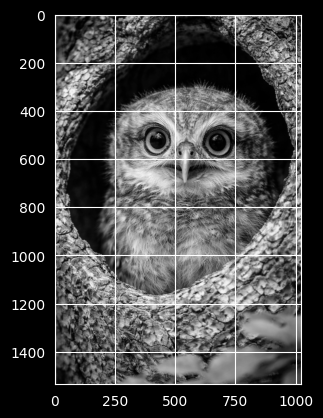

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def load_gray_scale_image(path):
    image_data = plt.imread(path)
    image_data = np.array(image_data)
    image_data = (0.2989 * image_data[:, :, 0] + 0.5870 * image_data[:, :, 1] + 0.1140 * image_data[:, :, 2]).astype(np.uint8)
    image_data = np.stack([image_data] * 3, axis=-1)
    return image_data

def plot_image(image_data):
    plt.imshow(image_data)
    plt.show()

image_data = load_gray_scale_image("../data/images/owl.jpg")

print(image_data.shape)

plot_image(image_data)

Replace all dark pixels (value below 30) with a red color and plot it with `plot_image`.

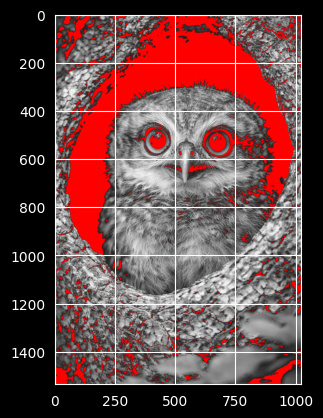

In [12]:
red_image_data = image_data.copy()
red_image_data[np.all(red_image_data < 30, axis=-1)] = [255,0,0]
plot_image(red_image_data)

#### Exercise 7: Aare revisited *(2 points)*

In this exercise, we work with daily water temperature data from the Aare river in Bern again. 

Source: [Hydrology Division, Federal Office for the Environment FOEN (2026)](https://www.hydrodaten.admin.ch/en/seen-und-fluesse/messstationen-temperatur).

First, we define some helper functions:

- `get_temperature_data`: returns the daily temperature data for 2004-2025
- `plot_temperature`: plots the the temperature for a given numpy array

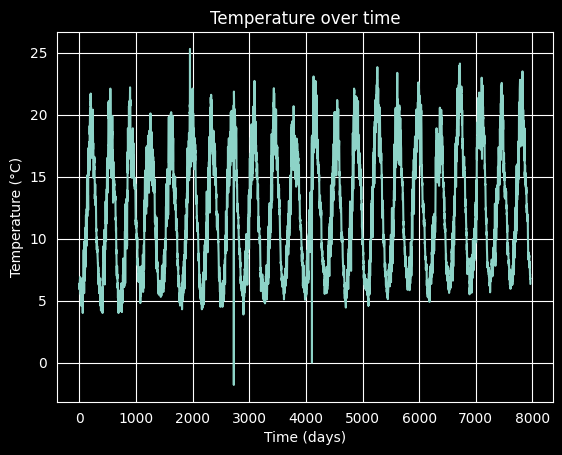

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_temperature_data():
    temperature_df = pd.read_csv(f"../data/csv/aare_temperature.csv", parse_dates=["timestamp"])
    
    return temperature_df["value"].to_numpy()



def plot_temperature(temperature_data, time_unit="days"):
    plt.plot(temperature_data)
    plt.xlabel(f"Time ({time_unit})")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Temperature over time")
    plt.show()


temperature = get_temperature_data()
plot_temperature(temperature)


Count how many days were bathable (i.e., water temperature was above 18 °C). Also give the percentage of bathable days compared to all days.

In [14]:
bathable_day = temperature > 18
bathable_day_count = sum(bathable_day)
print(f'Bathable day: {bathable_day_count} ({round(bathable_day_count / len(temperature) * 100,2)}%)')

Bathable day: 1347 (16.91%)


Set the temperature of all 'non-bathable' days to `np.nan`. Calculate the mean temperature of remaining days.

In [15]:
non_bathable_temperature = temperature.copy()
non_bathable_temperature[~bathable_day] = np.nan
print(f'Mean with nan values : {np.mean(non_bathable_temperature)}')
print(f'Mean without nan values : {np.nanmean(non_bathable_temperature)}')

Mean with nan values : nan
Mean without nan values : 19.85881959910913


#### Exercise 8: Vacation recommendations *(3 points)*

The code below defines five vacation destinations (`locations`) and four attributes for each (`attributes`). Each row describes one destination, and the columns represent scores on the factors scenery, activities, food, and nightlife.

Write a function `vacation_advisor` that asks the user whether they find each of the attributes important or not, and suggests the best vacation spot based on these preferences. If the user inputs `n` for all of the questions, print a message and ask again. Use techniques from the lecture to solve the exercise.

Hints:
- Translate the preferences (i.e., y/n) into a binary vector.
- Select attributes using the preferences to calculate a score per country.
- If multiple countries have the same score, return the first one.

Example interaction:
```raw
Is scenery important to you [y/n]?    > y
Is activities important to you [y/n]? > y
Is food important to you [y/n]?       > n
Is nightlife important to you [y/n]?  > n
Based on your preferences, the best destination is Australia
```

In [16]:
locations = np.array([ "Hawaii", "Thailand", "Italy", "Australia", "Japan"])

# List of attributes for each destination. Each column is an attribute. Each row a destination.
attributes = np.array([
    [8, 8, 7, 6],
    [7, 9, 8, 7],
    [8, 6, 9, 7],
    [9, 8, 8, 6],
    [7, 9, 7, 8]
])

# Declare attribute names and initialize boolean array with preferences
attribute_names = ["scenery", "activities", "food", "nightlife"]

In [17]:
def vacation_advisor():
    answered = False
    while not answered:
        preferences = []
        for attr in attribute_names:
            answer = input(f"Is {attr} important to you [y/n]? > ")
            preferences.append(answer == 'y')

        preferences = np.array(preferences)

        if np.any(preferences):
            scores = np.sum(attributes[:, preferences], axis=1) # we sum pref score by destination
            best_idx = np.argmax(scores) # take the first one with the highest score
            print(f"Based on your preferences, the best destination is {locations[best_idx]}")
            answered = True
        else :
            print("You answered 'n' to all attributes. Please try again.")

vacation_advisor()

Based on your preferences, the best destination is Thailand
